In [19]:
pip install scikit-learn matplotlib seaborn kneed

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


Requirement: Make sure all the libraries needed for the clustering project are available before starting.
Why written this way: scikit-learn for scaling, PCA and K-Means, matplotlib/seaborn for plotting the elbow curve and cluster visualization, kneed specifically for automatically detecting the "elbow" point in the WCSS curve instead of eyeballing the graph.

In [20]:
import pandas as pd
import sklearn
print("All good!")

All good!


Requirement: Confirm the installs from Cell 1 actually worked and the environment is ready.
Why written this way: A quick, low-risk sanity check before loading any real data .. if this fails, better to know now than after writing more code.

In [21]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Requirement: Load the raw mall customer data (the classic Kaggle "Mall Customer Segmentation" dataset with CustomerID, Gender, Age, Annual Income and Spending Score).
Why written this way: .head() gives an immediate visual check that the CSV loaded with the right columns before doing any processing.

In [22]:
import os
print(os.getcwd())
print(os.listdir())

c:\Users\Dell\Downloads\DataScienceProject1\DocumentsDataSciencecustomer-segmentation-project
['customer_segmentation.ipynb', 'Mall_Customers.csv']


Requirement: Debug step likely used to confirm the CSV file was actually sitting where Python expected it (a common early stumbling block when read_csv throws a "file not found" error).
Why written this way: os.getcwd() shows the notebook's current working directory and os.listdir() lists what files are actually there, making it easy to spot a path mismatch

In [23]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(200, 5)
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB
None
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


Requirement: Understand the size of the dataset, data types of each column and check for missing values before doing any modeling.
Why written this way: .shape confirms it's 200 rows as expected, .info() shows data types (important since Gender is categorical and won't be used numerically), .isnull().sum() confirms there's no missing data to clean so the project can move straight to feature selection.

In [24]:
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
X.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


Requirement: Pick which columns to actually cluster on. As explained in the notebook's own summary, CustomerID is meaningless (just an arbitrary ID) and Gender was deliberately kept out of the clustering.... it was intended to describe the clusters afterward, not to define them.
Why written this way: Only Age, Annual Income and Spending Score are numeric, business-relevant behavioral features.... exactly the variables that make sense for grouping customers by behavior.

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Requirement: K-Means uses Euclidean distance so features on very different scales (Income in the tens of thousands vs. Age in the tens) would unfairly dominate the distance calculation if left unscaled.
Why written this way: StandardScaler transforms each feature to have mean 0 and standard deviation 1, putting Age, Income and Spending Score on equal footing so no single feature dominates clustering just because of its raw numeric range.

In [26]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance retained:", sum(pca.explained_variance_ratio_))

Explained variance ratio: [0.44266167 0.33308378]
Total variance retained: 0.7757454566976747


Requirement: Reduce the 3 scaled features down to 2 dimensions, mainly to make the clusters easy to visualize on a 2D scatter plot while retaining as much information as possible.
Why written this way: n_components=2 compresses the data to 2 principal components. Printing explained_variance_ratio_ and its sum shows how much original information survives the compression ..... in this case about 78% of the variance was retained which is good enough to trust the 2D representation for clustering and plotting.

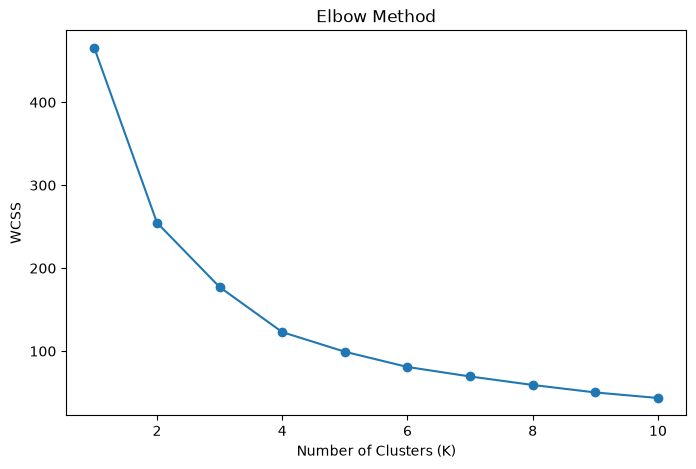

In [27]:
from sklearn.cluster import KMeans

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()

Requirement: In unsupervised clustering there's no "correct" number of groups given...the project required a data-driven way to choose K instead of guessing.
Why written this way: For each K from 1 to 10, a K-Means model is fit and its inertia_ (Within-Cluster Sum of Squares, WCSS .... how tightly packed the clusters are) is recorded. Plotting WCSS against K produces the classic "elbow curve" .... the point where adding more clusters stops giving much improvement is the natural candidate for K. n_init=10 runs K-Means 10 times with different centroid seeds and keeps the best result, avoiding a bad random initialization.

In [28]:
from kneed import KneeLocator

kl = KneeLocator(range(1, 11), wcss, curve='convex', direction='decreasing')
print("Optimal number of clusters (Elbow):", kl.elbow)

Optimal number of clusters (Elbow): 4


Requirement: Rather than visually guessing where the "elbow" is in the chart above, get an objective, reproducible number.
Why written this way: KneeLocator mathematically detects the elbow point on a convex, decreasing curve (exactly the shape a WCSS-vs-K plot takes) and confirmed K=4 as the best choice....matching what the notebook's summary reports.

K=2, Silhouette Score=0.4256
K=3, Silhouette Score=0.4136
K=4, Silhouette Score=0.4209
K=5, Silhouette Score=0.3931
K=6, Silhouette Score=0.3775
K=7, Silhouette Score=0.3871
K=8, Silhouette Score=0.3976
K=9, Silhouette Score=0.3899
K=10, Silhouette Score=0.4038


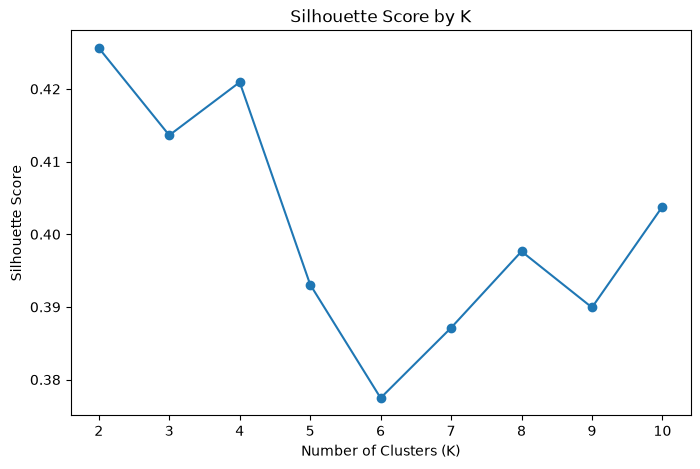

In [29]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
for k in range(2, 11):  # silhouette score needs at least 2 clusters
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    silhouette_scores.append(score)
    print(f"K={k}, Silhouette Score={score:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Score by K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.show()

Requirement: The Elbow Method alone can be subjective, so a second, independent metric was needed to confirm (or challenge) the choice of K=4.
Why written this way: Silhouette Score measures how well-separated and cohesive clusters are (ranges from -1 to 1, higher is better)  and unlike WCSS it can't be computed for K=1, hence the loop starts at range(2, 11). Each K's score is both printed and plotted so the trend across K values can be visually compared against the elbow result.

In [30]:
best_k = range(2, 11)[silhouette_scores.index(max(silhouette_scores))]
print("Best K based on Silhouette Score:", best_k)
print("All scores:", list(zip(range(2, 11), silhouette_scores)))

Best K based on Silhouette Score: 2
All scores: [(2, 0.4256333145815098), (3, 0.41362382732916375), (4, 0.4209286031083797), (5, 0.39308250061186895), (6, 0.37746991705880734), (7, 0.38712602291463294), (8, 0.39764625847952684), (9, 0.3899274079077436), (10, 0.4038166069314816)]


Requirement: Pin down exactly which K the Silhouette Score method recommends, to compare directly against the Elbow Method's K=4.
Why written this way: max(silhouette_scores) finds the best score and .index() maps it back to the corresponding K value. As the project summary notes, this came out slightly favoring K=2 — but K=4 was still chosen since it gives more actionable/business-useful segments and matches what this well-known dataset is typically segmented into.

In [31]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_pca)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,2
2,3,Female,20,16,6,0
3,4,Female,23,16,77,2
4,5,Female,31,17,40,2


Requirement: Actually assign each customer to one of the 4 final clusters, based on the K decided above.
Why written this way: n_clusters=4 locks in the chosen value; fit_predict both fits the model and returns cluster labels in one step, which are then stored directly as a new Cluster column in the original dataframe so every customer's raw attributes (Age, Income, Gender, etc.) stay linked to their assigned segment

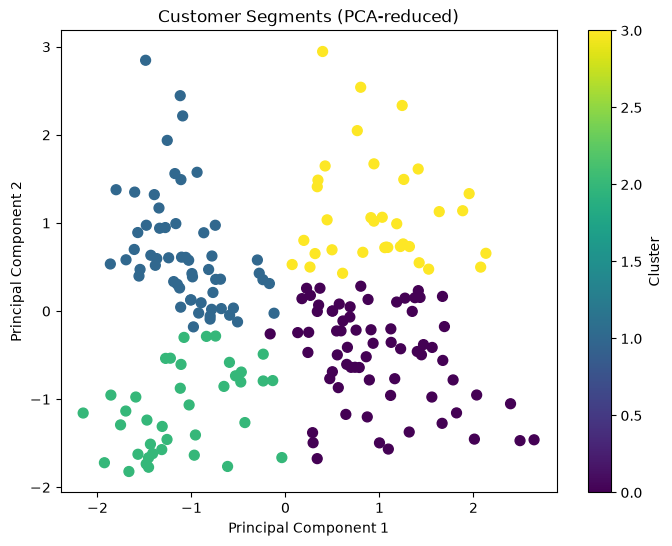

In [32]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'], cmap='viridis', s=50)
plt.title('Customer Segments (PCA-reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster')
plt.show()

Requirement: Give a visual, intuitive picture of how well-separated the 4 customer segments actually are.
Why written this way: Since PCA reduced the data to exactly 2 dimensions earlier, it can now be plotted directly as a 2D scatter plot, with each point colored by its assigned cluster (c=df['Cluster']). This makes it easy to see whether the clusters are visually distinct and well-formed rather than just trusting the numbers.

In [33]:
cluster_summary = df.groupby('Cluster').agg({
    'Age': 'mean',
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean',
    'CustomerID': 'count'
}).rename(columns={'CustomerID': 'Count'})

print(cluster_summary)

               Age  Annual Income (k$)  Spending Score (1-100)  Count
Cluster                                                              
0        52.144928           46.333333               40.072464     69
1        30.000000           79.086207               70.775862     58
2        25.605263           32.631579               67.500000     38
3        41.685714           88.228571               17.285714     35


Requirement: Turn abstract cluster numbers (0, 1, 2, 3) into meaningful business descriptions  what does each group actually look like?
Why written this way: Grouping by Cluster and averaging Age, Income, and Spending Score gives a clear numeric "profile" for each segment (this is exactly the data behind the results table in the project summary  e.g., Cluster 3 = high income, low spending). CustomerID is reused here purely as a counter (via 'count') to see how many customers fall into each segment and renamed to Count for clarity.

In [34]:
gender_breakdown = df.groupby('Cluster')['Gender'].value_counts(normalize=True) * 100
print(gender_breakdown)

Cluster  Gender
0        Female    57.971014
         Male      42.028986
1        Female    58.620690
         Male      41.379310
2        Female    60.526316
         Male      39.473684
3        Male      57.142857
         Female    42.857143
Name: proportion, dtype: float64


Requirement: Add the demographic detail (Gender) that was deliberately excluded from the clustering itself, to further describe.... not define..... each segment.
Why written this way: This is exactly why Gender was held back in Cell 6: it's used afterward, descriptively, to see if any cluster skews more male or female (e.g., the % Female column in the results table), which can inform marketing decisions without letting gender bias the actual grouping logic

# Customer Segmentation Project

This is my project 3 for Data Science internship (Unsupervised Learning).

## What is this project about
In this project I had to group mall customers into segments based on how they behave, but there was no labels telling me what the correct groups are, thats why its called unsupervised learning. Dataset has 200 customers with columns Age, Annual Income, Gender and Spending Score.

## What i did
- Only used Age, Income and Spending Score for the clustering. I removed CustomerID because its just a random number and doesnt mean anything, and i kept Gender separate to describe the clusters later, not to actually cluster on it
- Scaled the data using StandardScaler because Income and Age have very different ranges and that would mess up the distance calculation if not scaled
- Used PCA to reduce everything to 2 components, this kept about 78% of the variance
- To find best number of clusters i used Elbow Method and Silhouette Score. Elbow method showed K=4 was good, Silhouette score was actually a tiny bit higher at K=2 but almost same as K=4. I picked K=4 because 2 clusters is too simple for real business use and K=4 also matches what this dataset is known for
- Ran K-Means with K=4 and checked the average age/income/spending in each cluster to understand what type of customer each group actually is

## Results - the 4 customer types i found

| Cluster | Age | Income | Spending Score | Count | % Female |
|---|---|---|---|---|---|
| 0 - Older Moderate Spenders | 52.1 | $46.3k | 40.1 | 69 | 58.0% |
| 1 - High Value Trendsetters | 30.0 | $79.1k | 70.8 | 58 | 58.6% |
| 2 - Budget Conscious Explorers | 25.6 | $32.6k | 67.5 | 38 | 60.5% |
| 3 - Affluent Conservatives | 41.7 | $88.2k | 17.3 | 35 | 42.9% |

The most interesting group is Cluster 3, they have the highest income but spend the least. This is actually useful for a business because it means these people have money but for some reason arent spending, so they could be targeted with better offers.

## How to run
1. Install these:
2. Get the dataset from Kaggle (search "Mall Customer Segmentation Data") and put Mall_Customers.csv in the same folder
3. Open customer_segmentation.ipynb and run all the cells

## Tools used
Python, Pandas, Scikit-learn, Matplotlib, Kneed, Jupyter Notebook

## By
Urwa-til-Wosqa